<a href="https://colab.research.google.com/github/data602sps/assignments/blob/master/05_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Assignment 8**

# **Weeks 10 & 11- matplotlib & seaborn**
* In this homework assignment, you will explore and analyze a public dataset of your choosing. Since this assignment is “open-ended” in nature, you are free to expand upon the requirements below. However, you must meet the minimum requirments as indicated in each section.


* The preferred method for this analysis is in a .ipynb file. Feel free to use whichever platform of your choosing.  


### **Some data examples:**
•	https://www.data.gov/

•	https://opendata.cityofnewyork.us/

•	https://datasetsearch.research.google.com/

•	https://archive.ics.uci.edu/ml/index.php

### **Resources:**

•	https://pandas.pydata.org/pandas-docs/stable/getting_started/10min.html

•	https://www.oreilly.com/library/view/python-data-science/9781491912126/ch04.html

•	https://www.data-to-viz.com/



### **Headings or comments**
**You are required to make use of comments, or headings for each section.  You must explain what your code is doing, and the results of running your code.**  Act as if you were giving this assignment to your manager - you must include clear and descriptive information for each section.

### **You may work as a group or indivdually on this assignment.**


# Introduction

In this section, please describe the dataset you are using.  Include a link to the source of this data.  You should also provide some explanation on why you choose this dataset.

I went to NYC OpenData, searched by most recent and found this dataset called [Shooting Offenders](https://data.cityofnewyork.us/Public-Safety/Shooting-Offenders-2006-Present-/gdk4-mbsv/about_data). I'm selecting it for it's row size and street violence has been a concern of NYCers for a while and I'm interested on what the data says (at least about shootings).

______________
# Data Exploration
Import your dataset into your .ipynb, create dataframes, and explore your data.  

Include:

* Summary statistics means, medians, quartiles,
* Missing value information
* Any other relevant information about the dataset.  



In [9]:
import pandas as pd

# reading data as df
url = "https://data.cityofnewyork.us/resource/gdk4-mbsv.csv?$limit=20000"
df = pd.read_csv(url)
df.info()

# creating list of categorical columns
cat_cols = ["perp_age_group", "perp_sex", "perp_race"]

# empty list to use in for statement
unique_dfs = []

# for statement to fill unique's for the cols listed in cat_cols
for col in cat_cols:
    unique_df = (
        df[col]
        .drop_duplicates()
        .sort_values()
        .reset_index(drop=True)
        .to_frame(name=col)
    )
    
    unique_dfs.append(unique_df)

# output for each column in cat_col along with their uniques
for i in range(len(unique_dfs)):
    print(unique_dfs[i])



<class 'pandas.DataFrame'>
RangeIndex: 18901 entries, 0 to 18900
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   incident_key    18901 non-null  int64
 1   perp_id         18901 non-null  str  
 2   perp_age_group  18871 non-null  str  
 3   perp_sex        18901 non-null  str  
 4   perp_race       18901 non-null  str  
dtypes: int64(1), str(4)
memory usage: 1.3 MB
   perp_age_group
0            1020
1            1028
2           18-24
3            1822
4            2021
5             224
6           25-44
7           45-64
8             65+
9             940
10            <18
11        UNKNOWN
12            NaN
  perp_sex
0   FEMALE
1     MALE
2  UNKNOWN
                        perp_race
0  AMERICAN INDIAN/ALASKAN NATIVE
1        ASIAN / PACIFIC ISLANDER
2                           BLACK
3                  BLACK HISPANIC
4                         UNKNOWN
5                           WHITE
6                  WHI

`perp_age_group` is strange, there are clear groupings like 18-24, but then there are values like 1020, 1028, 1822, 2021, 224, 940, UNKNOWN, and NaN. The data also doesn't match the [data dictionary](https://data.cityofnewyork.us/api/views/gdk4-mbsv/files/0d8adad5-2516-49cd-a945-267868ce8fc5?download=true&filename=NYPD_Shootings_Data_Dictionary.xlsx) listed on the page. 

I'm not sure how to proceed. It could be a filtered list, since the fields like `per_sex` and `perp_race` don't have any weird unique's which would inform that the csv was corrupted in it's delimeter. My thoughts are that this is the true data, but it might have been clipped from the information they provided previously. 

For `perp_age_group` I can either remove those strange values or try and match them to existing groups. Or maybe just put them into UNKNOWN or convert UNKNOWN and all the strange values to NA 🤔

I will also rename all the columns because they don't need perp_ in front of them. 

# Data Wrangling

Perform data wrangling.  You are free to use your best judgment here.  If you are stuck, look at previous assignment.

In [19]:
import pandas as pd

# reading data as df
url = "https://data.cityofnewyork.us/resource/gdk4-mbsv.csv?$limit=20000"
df = pd.read_csv(url)

# Creating values I want to keep from perp_age_group
valid_age_groups = ["<18", "18-24", "25-44", "45-64", "65+", "UNKNOWN"]

df["perp_age_group"] = (
    df["perp_age_group"]
    .astype("string")
    .str.strip()
)

df["perp_age_group"] = df["perp_age_group"].where(
    df["perp_age_group"].isin(valid_age_groups),
    "UNKNOWN"
)

df = df.rename(columns={
    "perp_id": "id",
    "perp_age_group": "age_group",
    "perp_sex": "sex",
    "perp_race": "race"
})

print(df["age_group"].value_counts(dropna=False), "\n", "---")

df.info()

age_group
18-24      6771
25-44      6166
UNKNOWN    3400
<18        1814
45-64       690
65+          60
Name: count, dtype: int64[pyarrow] 
 ---
<class 'pandas.DataFrame'>
RangeIndex: 18901 entries, 0 to 18900
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   incident_key  18901 non-null  int64 
 1   id            18901 non-null  str   
 2   age_group     18901 non-null  string
 3   sex           18901 non-null  str   
 4   race          18901 non-null  str   
dtypes: int64(1), str(3), string(1)
memory usage: 1.3 MB


That looks much better. I would usually just match junk information like what we saw in age_group into NA, however, UNKNOWN is more meaningful for this dataset since it already exists. Although, whatever analysis we perform will have an * regarding the data quality. 

# Visualizations

The main purpose of this assignment is to practice creating various visualizations using the matplotlib and seaborn library.

### **Part 1:**
Using matplotlib, create ***two or more plots*** that incorporate at least **5** of the following properties:

Note: these properties vary based on your data.  The goal is to practice creating visualizations and modifying its properties.

*   Use and change a legend position
*   Change a legend font size
*   Place a legend outside of the plot
*   Create a single legend for all subplots
*   Change the title and x/y labels
*   Change the marker, line colors, and line width
*   Add annotations
*   Modify Axis Text Ticks/Labels
*   Change size of axis Labels
*   Your own choice not included above


Plots that you can create **include**:

*   Scatter Plot
*   Bar plot
*   Line Chart
*   Multi Plots (e.g. using .subplot()
*   Histogram

You can add another plot not listed here if it works better for your data.  This is not a complete list of plots to create.

### **Part 2:**

Recreate the visualizations above using the Seaborn library as best as possible.  


**You are required to explain what each of your plots is representing. Plots without comments will not be accepted.**  In addition, please explain the properties you are showcasing.


### **Part 3:**
In a comment or text box, explain the differences between creating a plot in matplotlib and seaborn, based on your above plots.



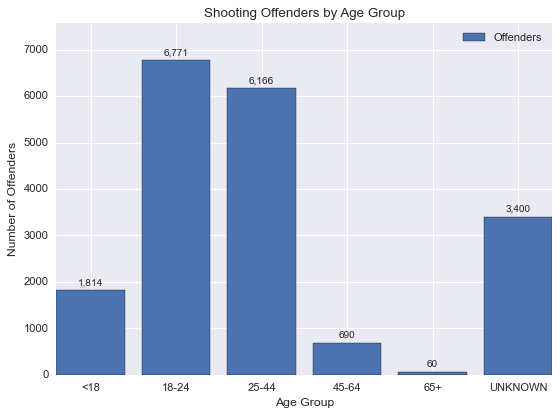

In [50]:
import matplotlib.pyplot as plt

# creating variable to store altered df
age_counts = df["age_group"].value_counts()

# creating an index to order the age column 
age_order = ["<18", "18-24", "25-44", "45-64", "65+", "UNKNOWN"]

# indexing the column
age_counts = (
    df["age_group"]
    .value_counts()
    .reindex(age_order)
)

# creating bars
bars = plt.bar(
    age_counts.index,
    age_counts.values,
    label="Offenders"
)

# creating bar labels
plt.bar_label(
    bars,
    labels=[f"{v:,}" for v in age_counts.values],
    padding=3,
    fontsize=9
)

# increasing the y limit to accomadate the bar labels
plt.ylim(0, age_counts.max() * 1.12)

# labeling the graph
plt.title("Shooting Offenders by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Offenders")

# change legend position & font
plt.legend(loc="upper right", fontsize=10)

plt.style.use("seaborn-v0_8")
plt.show()

This bar chart shows the number of shooting offenders in each age group.I'm showing `age_group` on the x-axis (categorical) and number of offenses in the y-axis (count of rows per group). It's ordered by age_group, so we have the youngest furthest to the left and oldest furthest to the right—with the right most column being UNKNOWN values.

We can see that the 18-24 group has the highest amount of offenders. Although, note that the UNKNOWN category, if the data wasn't dirty, could influence the validity of this conclusion. 

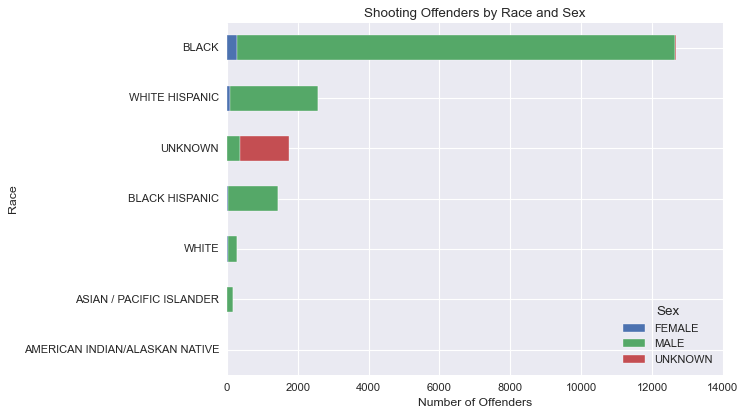

In [59]:
import matplotlib.pyplot as plt

# Create race-by-sex count table
race_sex_counts = (
    df.groupby(["race", "sex"])
    .size()
    .unstack(fill_value=0)
)

# Sort races by total count
race_sex_counts = race_sex_counts.loc[
    race_sex_counts.sum(axis=1).sort_values(ascending=True).index
]

# Create horizontal stacked bar chart
ax = race_sex_counts.plot(
    kind="barh",
    stacked=True,
)

plt.title("Shooting Offenders by Race and Sex")
plt.xlabel("Number of Offenders")
plt.ylabel("Race")

plt.legend(
    title="Sex",
    loc="lower right",
    fontsize=10
)

plt.style.use("seaborn-v0_8")
plt.show()

This stacked horizontal bar chart shows the number of shooting offenders by race and sex. I’m showing race on the y-axis as the categorical variable, and the number of offenders on the x-axis as the count of rows per group. Each bar is split by sex, so the chart shows both the total number of offenders in each race category and how that total breaks down by male, female, and unknown.

The chart is ordered by total count, with the largest race category at the top. We can see that BLACK has the highest number of offenders by a large margin, followed by WHITE HISPANIC, UNKNOWN, and BLACK HISPANIC. Across most race categories, male offenders make up the largest share. The UNKNOWN race category is also noticeable, which matters because missing or unclear race values could affect how strongly we interpret the results.

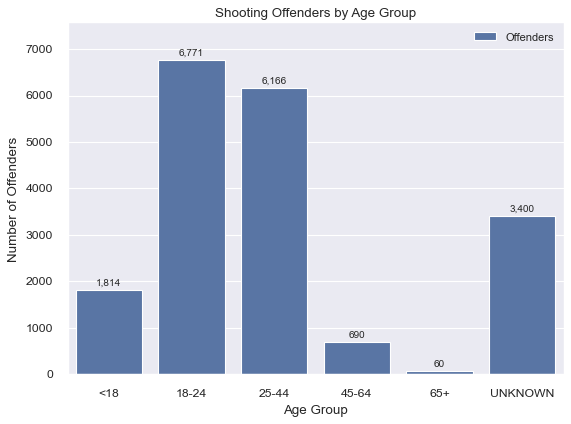

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

# setting seaborn theme to roughly match matplotlib seaborn style
sns.set_theme(style="darkgrid")

# creating index/order for age groups
age_order = ["<18", "18-24", "25-44", "45-64", "65+", "UNKNOWN"]

# creating ordered counts
age_counts = (
    df["age_group"]
    .value_counts()
    .reindex(age_order)
)

# creating plot
ax = sns.barplot(
    x=age_counts.index,
    y=age_counts.values,
    label="Offenders"
)

# creating bar labels
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{v:,}" for v in age_counts.values],
        padding=3,
        fontsize=9
    )

# increasing y limit to accommodate bar labels
ax.set_ylim(0, age_counts.max() * 1.12)

# labeling the graph
ax.set_title("Shooting Offenders by Age Group")
ax.set_xlabel("Age Group")
ax.set_ylabel("Number of Offenders")

# change legend position & font
ax.legend(loc="upper right", fontsize=10)

plt.show()

I recreated the bar plot, almost exactly. I think the font size might be different, put that's just picking hairs. 

The plot is similar to the plot created via matlib's pyplot so I'll quote it below: 

*This bar chart shows the number of shooting offenders in each age group.I'm showing `age_group` on the x-axis (categorical) and number of offenses in the y-axis (count of rows per group). It's ordered by age_group, so we have the youngest furthest to the left and oldest furthest to the right—with the right most column being UNKNOWN values.*

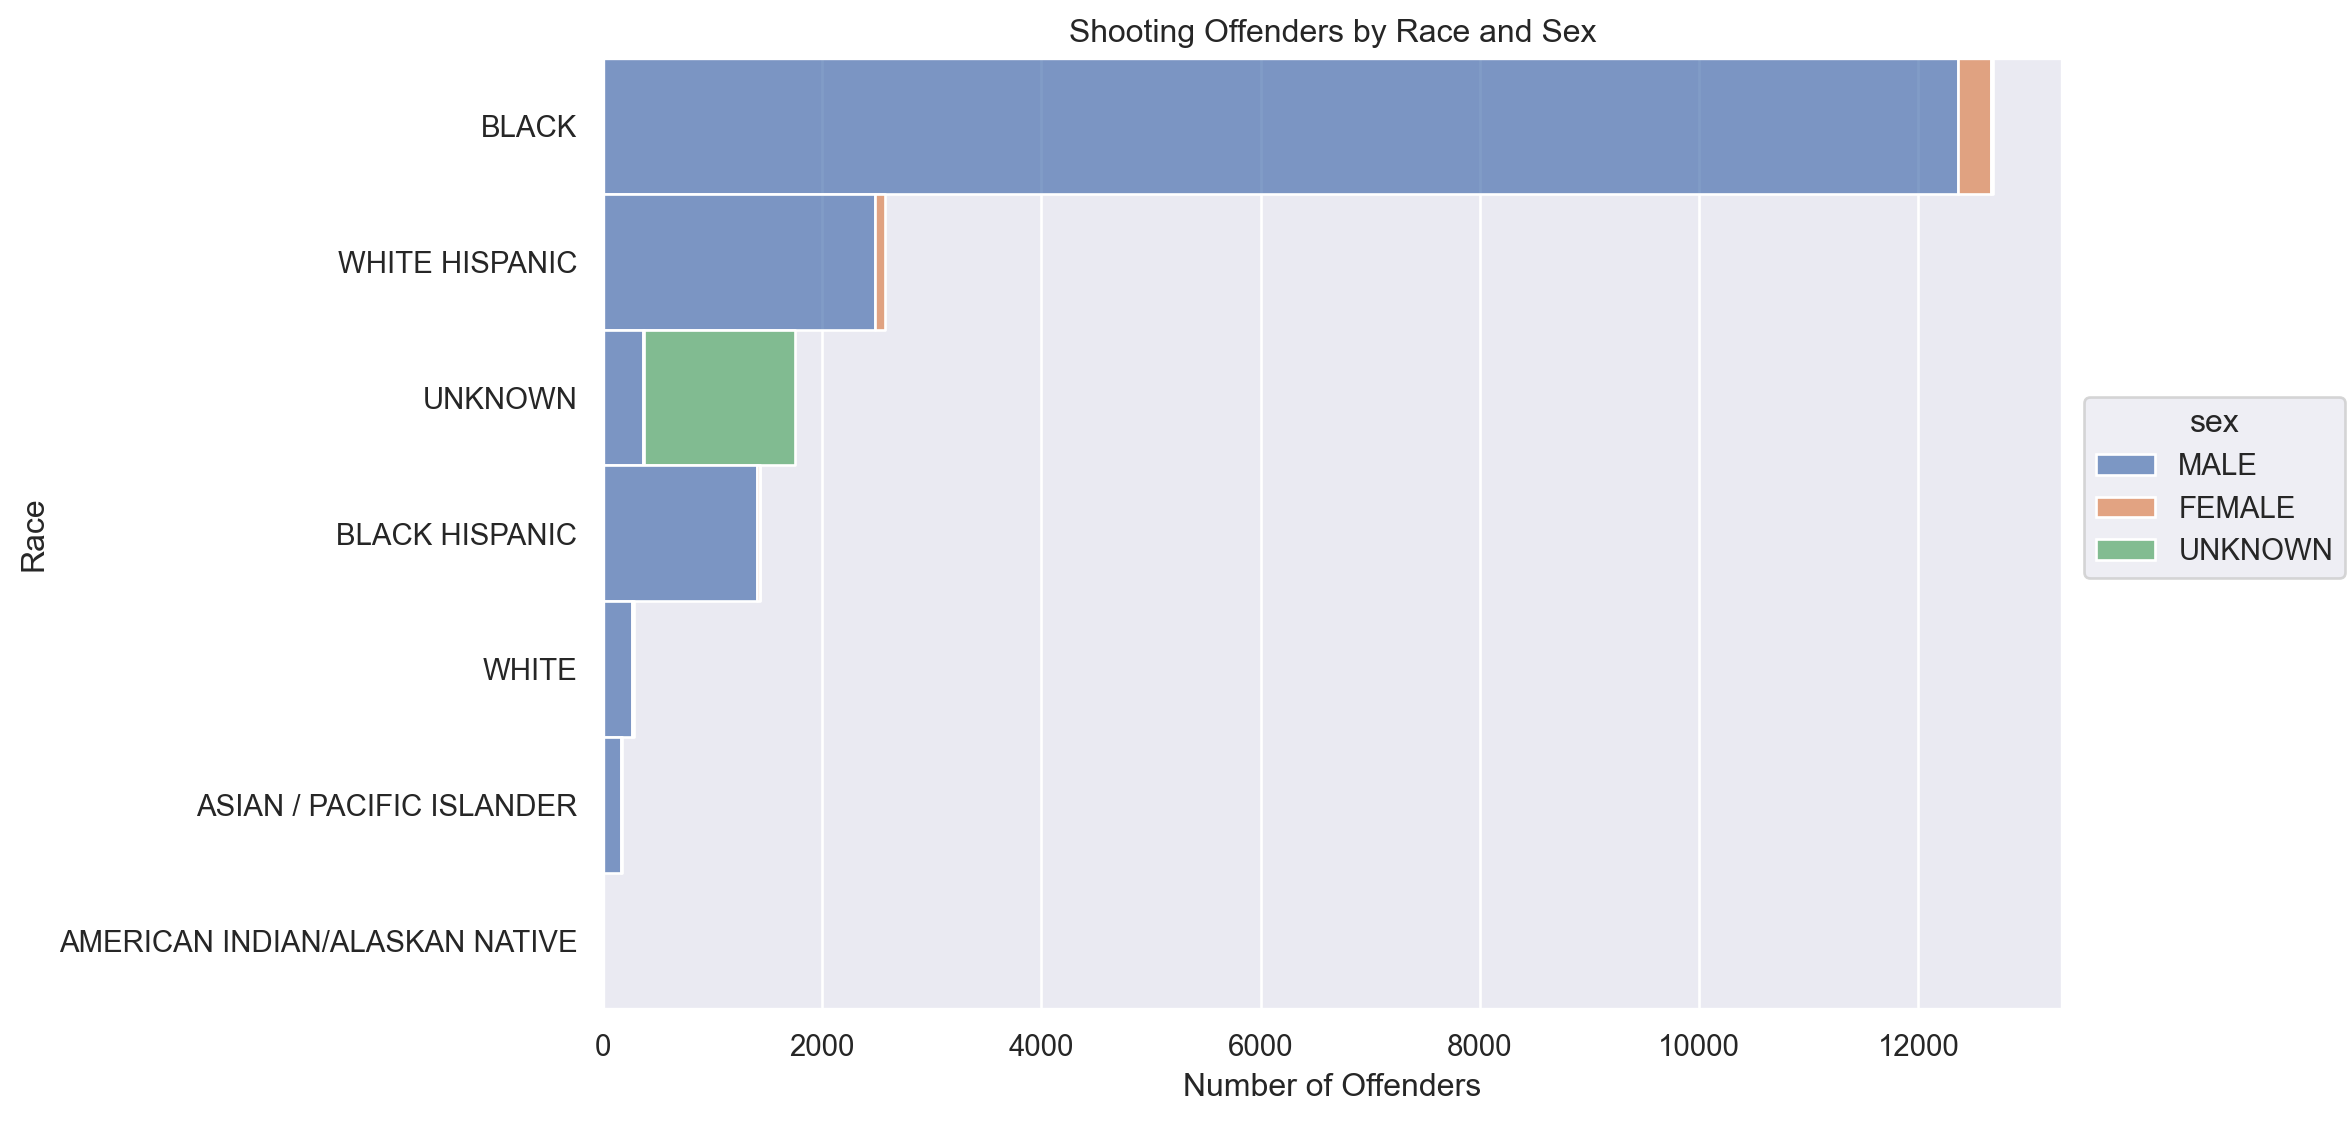

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so

race_order = (
    df["race"]
    .value_counts()
    .sort_values(ascending=False)
    .index
)

(
    so.Plot(df, y="race", color="sex")
    .scale(y=so.Nominal(order=race_order))
    .add(so.Bars(), so.Count(), so.Stack())
    .label(
        title="Shooting Offenders by Race and Sex",
        x="Number of Offenders",
        y="Race"
    )
.theme({"figure.figsize": (11, 6)}, )
)


This was a little confusing to make, but I was able to do it and the code is so little. So, I had to lookup seaborn.objects, using the seaborn documentation online and viewing the [stack](https://seaborn.pydata.org/generated/seaborn.objects.Stack.html#seaborn.objects.Stack) page. I was having trouble moving the legend, I was having a hard time so I gave up 😭 and I wanted to see if I could order the sex within the stacked columns but I felt I spent too long with this portion of the assignment!

# Conclusions  

After exploring your dataset, provide a short summary of what you noticed from this dataset.  

This is one of the stranger datasets that I've worked with, especially with the funny happenings with the `age-group` column. The data is interesting as it kinda makes sense that the 18+ age group would cause the crimes and women commit less crimes than men (per each racial group). We also see that in NYC black's are the highest shooting offenders than other racial groups.

It was kinda fun to work with, since it was pretty straight forward to fix the errors and there weren't any crazy str columns to try and regex into meaningful data (which is the most annoying data types to deal with).